<a href="https://colab.research.google.com/github/nicholastimmann-cyber/Travel_Tide_CustomerSegmentation/blob/main/Kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


KMeans for 93%

In [ ]:
directory = "/content/drive/MyDrive/Colab Notebooks"

#del user_pca

user_pca_93 = pd.read_csv(f'{directory}/user_pca_0.93.csv', index_col="user_id")
print(user_pca_93.shape)
user_pca_93.head()

(5998, 17)


,pca_0,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,pca_10,pca_11,pca_12,pca_13,pca_14,pca_15,pca_16
user_id,,,,,,,,,,,,,,,,,
23557,-2.276954,-0.280549,-3.994869,3.351051,1.353663,-2.158080,0.439640,-1.096351,0.283748,0.768888,-0.387076,-0.350768,-0.583932,0.785300,-0.504646,2.163029,-0.776706
94883,-0.424352,-1.658170,0.250756,-1.135979,1.647112,1.349490,-0.212745,-0.873587,0.116600,0.918659,-0.909389,-0.768912,1.202748,-0.266835,-0.058627,0.518649,0.415329
101486,-1.287191,-0.382120,-1.005654,0.828737,1.798240,0.309894,0.613401,-0.949464,0.423852,0.459181,1.769316,-0.123174,-1.489643,-1.907205,0.211602,0.633302,-0.135858
101961,3.112392,0.683799,-2.300496,-1.855919,0.267935,-0.750818,0.214058,-0.437059,0.166973,0.986444,-0.120315,-0.810117,0.552955,-0.060158,0.377945,0.104290,0.921921
106907,-4.985648,4.754590,2.781044,0.489885,1.270154,-1.434827,0.540270,0.750844,0.074372,0.149019,0.810504,-0.945046,-0.266898,-0.370588,-0.115816,-0.041864,0.500413


In [ ]:
del user_pca

finde zwischen 4 und 10 Cluster: Quelle

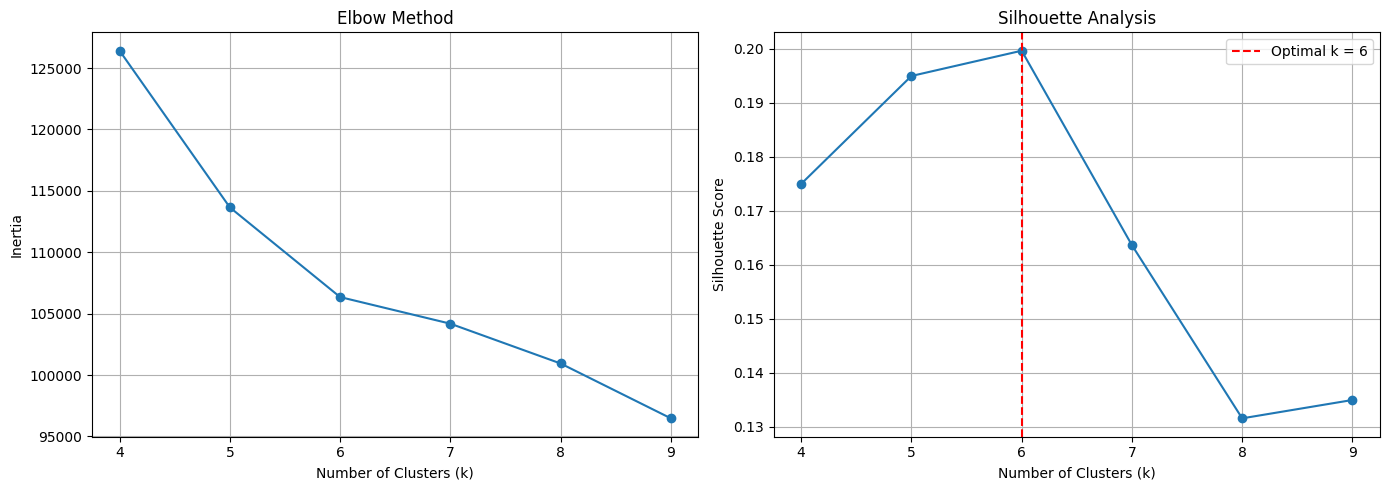

Optimal number of clusters based on Silhouette: 6


In [ ]:
# Definiere den Bereich für die Anzahl der Cluster, die getestet werden sollen (z. B. 2 bis 10)
range_n_clusters = range(4, 10)
silhouette_scores = []
inertia_values = []

# Führe K-Means für jeden k-Wert durch und berechne den Silhouette-Score
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(user_pca_93)
    silhouette_avg = silhouette_score(user_pca_93, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    inertia_values.append(kmeans.inertia_)

# --- Find best silhouette k ---
optimal_n_clusters = range_n_clusters[np.argmax(silhouette_scores)]

# --- Create subplots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Elbow Plot ---
ax1.plot(range_n_clusters, inertia_values, marker='o')
ax1.set_title("Elbow Method")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia")
ax1.grid(True)

# --- Silhouette Plot ---
ax2.plot(range_n_clusters, silhouette_scores, marker='o')
ax2.axvline(optimal_n_clusters, color='red', linestyle='--', label=f'Optimal k = {optimal_n_clusters}')
ax2.set_title("Silhouette Analysis")
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Optimal number of clusters based on Silhouette: {optimal_n_clusters}")

In [ ]:
#optimal_n_clusters = 6 for 93%

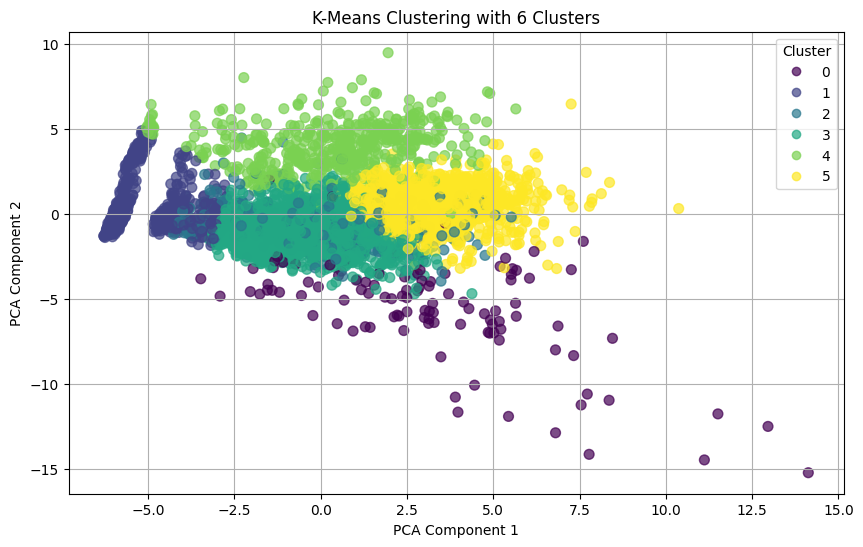

In [ ]:
# Perform K-Means clustering using the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_n_clusters, random_state=42)

# Assign cluster labels to each observation
user_pca_93['group'] = kmeans.fit_predict(user_pca_93)

# Plot the first two PCA components to visualize the clusters
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    user_pca_93.iloc[:, 0],   # first PCA component
    user_pca_93.iloc[:, 1],   # second PCA component
    c=user_pca_93['group'],   # color points by cluster assignment
    cmap='viridis',           # color palette
    s=50,                     # point size
    alpha=0.7                 # transparency
)

# Plot formatting
plt.title(f'K-Means Clustering with {optimal_n_clusters} Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)

# Add legend showing cluster groups
legend = plt.legend(*scatter.legend_elements(), title='Cluster')
plt.show()

In [ ]:
# Save the user_id -> cluster group mapping to a CSV file
user_pca_93['group'].to_csv(f'{directory}/user_segment_0.93.csv')

# Display the cluster assignment
user_pca_93['group']

,group
user_id,
23557,2
94883,3
101486,3
101961,5
106907,4
...,...
792549,5
796032,4
801660,3


KMeans for 95%

In [ ]:
directory = "/content/drive/MyDrive/Colab Notebooks"

#del user_pca

user_pca_95 = pd.read_csv(f'{directory}/user_pca.csv.0.95', index_col="user_id")
print(user_pca_95.shape)
user_pca_95.head()

(5998, 18)


,pca_0,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,pca_10,pca_11,pca_12,pca_13,pca_14,pca_15,pca_16,pca_17
user_id,,,,,,,,,,,,,,,,,,
23557,-2.276954,-0.280549,-3.994869,3.351051,1.353663,-2.158080,0.439640,-1.096351,0.283748,0.768888,-0.387076,-0.350768,-0.583932,0.785300,-0.504646,2.163029,-0.776706,0.430427
94883,-0.424352,-1.658170,0.250756,-1.135979,1.647112,1.349490,-0.212745,-0.873587,0.116600,0.918659,-0.909389,-0.768912,1.202748,-0.266835,-0.058627,0.518649,0.415329,0.005887
101486,-1.287191,-0.382120,-1.005654,0.828737,1.798240,0.309894,0.613401,-0.949464,0.423852,0.459181,1.769316,-0.123174,-1.489643,-1.907205,0.211602,0.633302,-0.135858,0.143465
101961,3.112392,0.683799,-2.300496,-1.855919,0.267935,-0.750818,0.214058,-0.437059,0.166973,0.986444,-0.120315,-0.810117,0.552955,-0.060158,0.377945,0.104290,0.921921,0.499585
106907,-4.985648,4.754590,2.781044,0.489885,1.270154,-1.434827,0.540270,0.750844,0.074372,0.149019,0.810504,-0.945046,-0.266898,-0.370588,-0.115816,-0.041864,0.500413,-0.645973


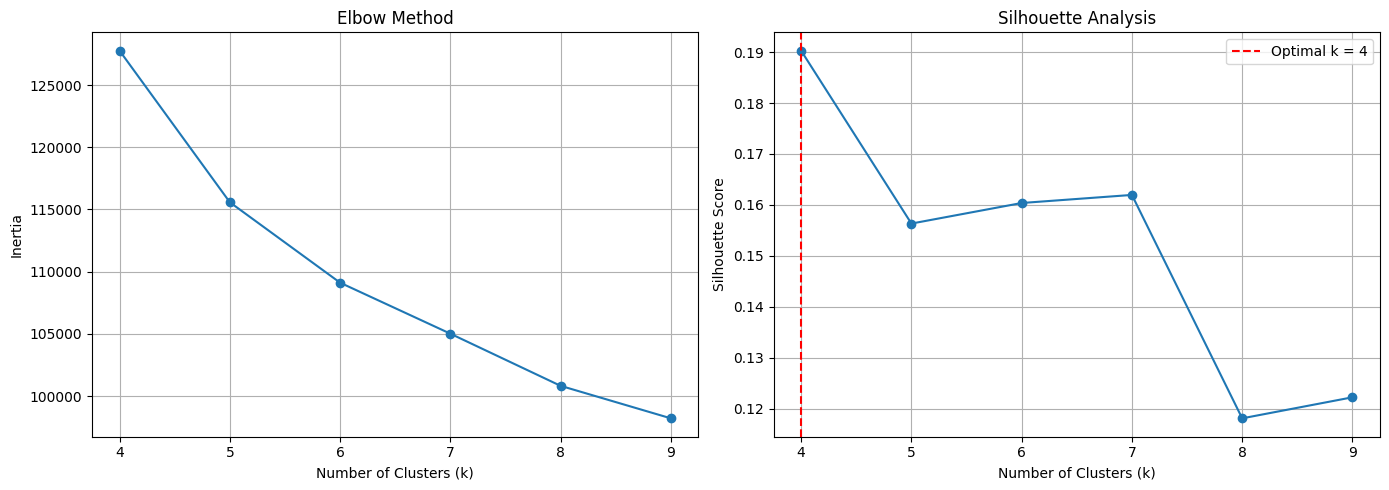

Optimal number of clusters based on Silhouette: 4


In [ ]:
# Definiere den Bereich für die Anzahl der Cluster, die getestet werden sollen (z. B. 2 bis 10)
range_n_clusters = range(4, 10)
silhouette_scores = []
inertia_values = []

# Führe K-Means für jeden k-Wert durch und berechne den Silhouette-Score
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(user_pca_95)
    silhouette_avg = silhouette_score(user_pca_95, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    inertia_values.append(kmeans.inertia_)

# --- Find best silhouette k ---
optimal_n_clusters = range_n_clusters[np.argmax(silhouette_scores)]

# --- Create subplots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Elbow Plot ---
ax1.plot(range_n_clusters, inertia_values, marker='o')
ax1.set_title("Elbow Method")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia")
ax1.grid(True)

# --- Silhouette Plot ---
ax2.plot(range_n_clusters, silhouette_scores, marker='o')
ax2.axvline(optimal_n_clusters, color='red', linestyle='--', label=f'Optimal k = {optimal_n_clusters}')
ax2.set_title("Silhouette Analysis")
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Optimal number of clusters based on Silhouette: {optimal_n_clusters}")

In [ ]:
#optimal_n_clusters = 4 for 95%

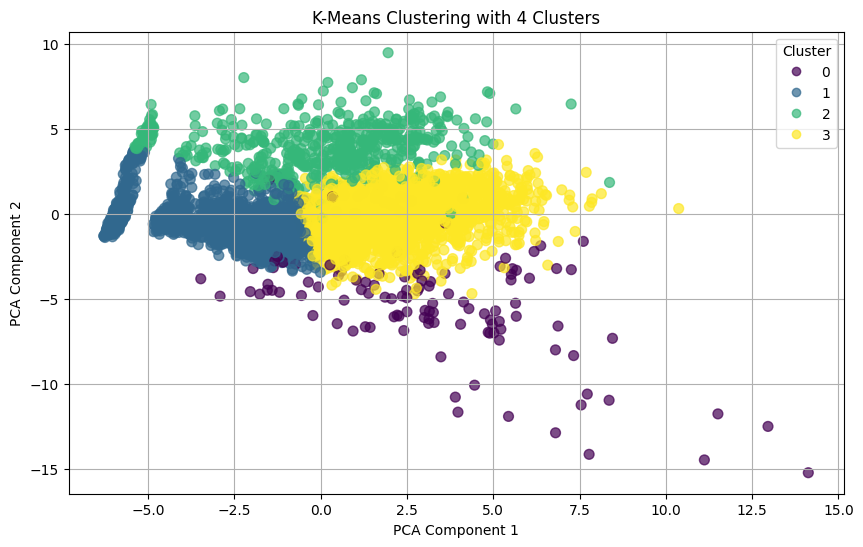

In [ ]:
# Perform K-Means clustering using the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_n_clusters, random_state=42)

# Assign cluster labels to each observation
user_pca_95['group'] = kmeans.fit_predict(user_pca_95)

# Plot the first two PCA components to visualize the clusters
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    user_pca_95.iloc[:, 0],   # first PCA component
    user_pca_95.iloc[:, 1],   # second PCA component
    c=user_pca_95['group'],   # color points by cluster assignment
    cmap='viridis',           # color palette
    s=50,                     # point size
    alpha=0.7                 # transparency
)

# Plot formatting
plt.title(f'K-Means Clustering with {optimal_n_clusters} Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)

# Add legend showing cluster groups
legend = plt.legend(*scatter.legend_elements(), title='Cluster')
plt.show()

In [ ]:
# Save the user_id -> cluster group mapping to a CSV file
user_pca_95['group'].to_csv(f'{directory}/user_segment_0.95.csv')

# Display the cluster assignment
user_pca_95['group']

,group
user_id,
23557,1
94883,3
101486,1
101961,3
106907,2
...,...
792549,3
796032,2
801660,3


KMeans for 90%

In [ ]:
directory = "/content/drive/MyDrive/Colab Notebooks"

#del user_pca

user_pca_90 = pd.read_csv(f'{directory}/user_pca.csv.0.90', index_col="user_id")
print(user_pca_90.shape)
user_pca_90.head()

(5998, 15)


,pca_0,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,pca_10,pca_11,pca_12,pca_13,pca_14
user_id,,,,,,,,,,,,,,,
23557,-2.276954,-0.280549,-3.994869,3.351051,1.353663,-2.158080,0.439640,-1.096351,0.283748,0.768888,-0.387076,-0.350768,-0.583932,0.785300,-0.504646
94883,-0.424352,-1.658170,0.250756,-1.135979,1.647112,1.349490,-0.212745,-0.873587,0.116600,0.918659,-0.909389,-0.768912,1.202748,-0.266835,-0.058627
101486,-1.287191,-0.382120,-1.005654,0.828737,1.798240,0.309894,0.613401,-0.949464,0.423852,0.459181,1.769316,-0.123174,-1.489643,-1.907205,0.211602
101961,3.112392,0.683799,-2.300496,-1.855919,0.267935,-0.750818,0.214058,-0.437059,0.166973,0.986444,-0.120315,-0.810117,0.552955,-0.060158,0.377945
106907,-4.985648,4.754590,2.781044,0.489885,1.270154,-1.434827,0.540270,0.750844,0.074372,0.149019,0.810504,-0.945046,-0.266898,-0.370588,-0.115816


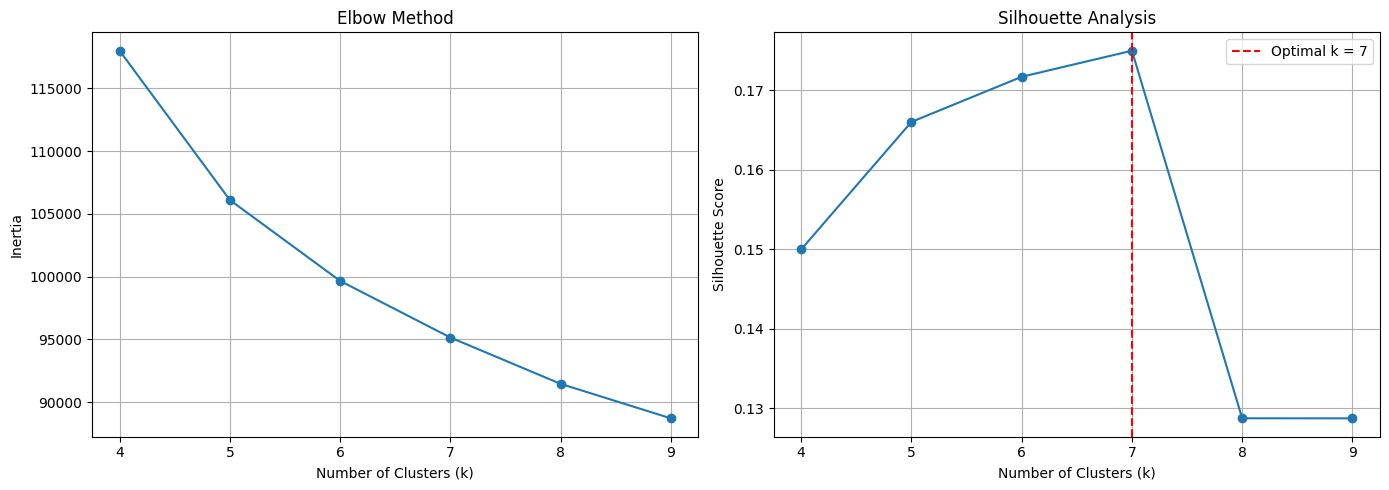

Optimal number of clusters based on Silhouette: 7


In [ ]:
# Definiere den Bereich für die Anzahl der Cluster, die getestet werden sollen (z. B. 2 bis 10)
range_n_clusters = range(4, 10)
silhouette_scores = []
inertia_values = []

# Führe K-Means für jeden k-Wert durch und berechne den Silhouette-Score
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(user_pca_90)
    silhouette_avg = silhouette_score(user_pca_90, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    inertia_values.append(kmeans.inertia_)

# --- Find best silhouette k ---
optimal_n_clusters = range_n_clusters[np.argmax(silhouette_scores)]

# --- Create subplots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Elbow Plot ---
ax1.plot(range_n_clusters, inertia_values, marker='o')
ax1.set_title("Elbow Method")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia")
ax1.grid(True)

# --- Silhouette Plot ---
ax2.plot(range_n_clusters, silhouette_scores, marker='o')
ax2.axvline(optimal_n_clusters, color='red', linestyle='--', label=f'Optimal k = {optimal_n_clusters}')
ax2.set_title("Silhouette Analysis")
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Optimal number of clusters based on Silhouette: {optimal_n_clusters}")

In [ ]:
#Optimal number of clusters for 90% = 7

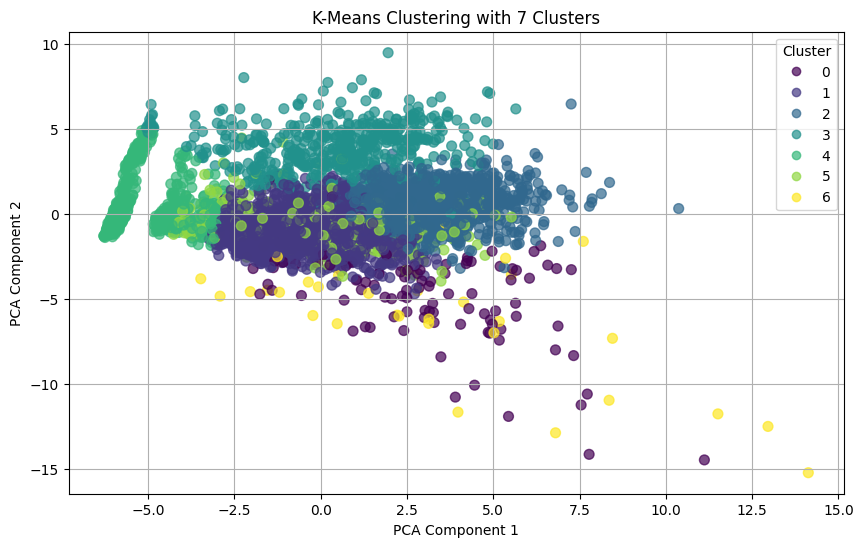

In [ ]:
# Perform K-Means clustering using the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_n_clusters, random_state=42)

# Assign cluster labels to each observation
user_pca_90['group'] = kmeans.fit_predict(user_pca_90)

# Plot the first two PCA components to visualize the clusters
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    user_pca_90.iloc[:, 0],   # first PCA component
    user_pca_90.iloc[:, 1],   # second PCA component
    c=user_pca_90['group'],   # color points by cluster assignment
    cmap='viridis',           # color palette
    s=50,                     # point size
    alpha=0.7                 # transparency
)

# Plot formatting
plt.title(f'K-Means Clustering with {optimal_n_clusters} Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)

# Add legend showing cluster groups
legend = plt.legend(*scatter.legend_elements(), title='Cluster')
plt.show()

In [ ]:
# Save the user_id -> cluster group mapping to a CSV file
user_pca_90['group'].to_csv(f'{directory}/user_segment_0.90.csv')

# Display the cluster assignment
user_pca_90['group']

,group
user_id,
23557,5
94883,1
101486,1
101961,2
106907,3
...,...
792549,2
796032,3
801660,1
